# SAE Training on Federated Learning Checkpoints

In [1]:
# Cell 1: Environment Bootstrap
import os
REPO_URL = "https://github.com/ha405/FedMI.git"
BRANCH = "cvpr"

if not os.path.exists("FedMI"):
    get_ipython().system(f"git clone -b {BRANCH} {REPO_URL}")
else:
    # Update repo if already exists to get latest fixes
    get_ipython().system(f"cd FedMI && git pull origin {BRANCH}")

os.chdir("FedMI")

from fedmi.env import setup, CHECKPOINT_DIR, DATA_DIR
setup()

# Install dependencies required by the original notebook
%pip install -q einops opencv-python scikit-image overcomplete

Cloning into 'FedMI'...
remote: Enumerating objects: 815, done.
remote: Counting objects: 100% (443/443), done.
remote: Compressing objects: 100% (321/321), done.
remote: Total 815 (delta 229), reused 308 (delta 120), pack-reused 372 (from 1)
Receiving objects: 100% (815/815), 56.15 MiB | 22.54 MiB/s, done.
Resolving deltas: 100% (327/327), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 kB 3.7 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
from typing import List
import numpy as np
import matplotlib.pyplot as plt
from einops import rearrange
from torch.utils.data import DataLoader, TensorDataset
import json
import os

import overcomplete
from overcomplete.sae import TopKSAE, JumpSAE, BatchTopKSAE, train_sae
from overcomplete.visualization import show, overlay_top_heatmaps

import sys
# sys.path.append('..') # Original path, now unnecessary as we are in the repo root

from core.config import ExperimentConfig
from core.dataset import get_dataset, get_test_dataloader

# ==========================================
# ResNet10 Architecture Definition
# ==========================================
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels, out_channels, kernel_size=3,
            stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels, kernel_size=3,
            stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(identity)

        out += identity
        out = self.relu(out)

        return out


class ResNet10(nn.Module):
    def __init__(self, num_classes=1000, in_channels=3):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels, 64, kernel_size=7,
            stride=2, padding=3, bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # stages
        self.block1 = nn.Sequential(BasicBlock(64, 64, stride=1))
        self.block2 = nn.Sequential(BasicBlock(64, 128, stride=2))
        self.block3 = nn.Sequential(BasicBlock(128, 192, stride=2))
        self.block4 = nn.Sequential(BasicBlock(192, 256, stride=2))

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

# ==========================================
# Utility Functions
# ==========================================

def get_model(config) -> nn.Module:
    in_channels = 1 if config.dataset_name == "MNIST" else 3
    # Use ResNet10, adapting for input channels and specific task classes
    return ResNet10(
        num_classes=5,
        in_channels=in_channels
    ).to(config.device)

def load_config_and_data(config_path):
    with open(config_path, 'r') as f:
        config_dict = json.load(f)
    # Filter out comment keys
    config_dict = {k: v for k, v in config_dict.items() if not k.startswith('_')}
    config = ExperimentConfig(**config_dict)
    # Patch paths for Cloud environment
    config.data_root = DATA_DIR
    _, testset = get_dataset(config)
    test_loader = get_test_dataloader(testset, config)
    return config, testset, test_loader

def load_model_from_checkpoint(config, path):
    model = get_model(config)
    state_dict = torch.load(path, map_location=config.device)
    model.load_state_dict(state_dict['model_state_dict'])
    model.eval()
    return model

def extract_activations(model, dataloader, config):
    model.eval()
    activations = []
    labels = []
    with torch.no_grad():
        for batch in dataloader:
            x, y = batch
            x = x.to(config.device)

            # Replicate the forward pass up to the target extraction layer (block4)
            x = model.conv1(x)
            x = model.bn1(x)
            x = model.relu(x)
            x = model.maxpool(x)

            x = model.block1(x)
            x = model.block2(x)
            x = model.block3(x)
            x = model.block4(x) # We extract from block4, the last spatial representations

            b, c, h, w = x.shape
            x_flat = rearrange(x, 'b c h w -> (b h w) c')
            activations.append(x_flat.cpu())
            y_rep = y.unsqueeze(1).repeat(1, h*w).reshape(-1)
            labels.append(y_rep.cpu())

    activations = torch.cat(activations, dim=0)
    labels = torch.cat(labels, dim=0)

    print(f"Extracted activations from block4. Shape: {activations.shape}") # Should be [N, 256] for ResNet10's block4
    return activations, labels

In [3]:
def train_jump_sae(activations, scenario_name, config):
    subset_size = min(10000, len(activations))
    activations_subset = activations[:subset_size]
    dataset = TensorDataset(activations_subset.to(config.device))
    dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

    print(f"\n--- Training JumpReLU SAE for {scenario_name} ---")
    print(f"Using {subset_size} samples of size {activations.shape[-1]} for SAE training.")

    num_features = activations.shape[-1]
    sae_jump = JumpSAE(num_features, nb_concepts=num_features * 4, bandwidth=1e-2, kernel='silverman', device=config.device)
    optimizer_jump = torch.optim.Adam(sae_jump.parameters(), lr=3e-3)

    desired_sparsity = 0.10

    def criterion_jump(x, x_hat, pre_codes, codes, dictionary):
        loss = (x - x_hat).square().mean()
        sparsity = (codes > 0).float().mean().detach()
        if sparsity > desired_sparsity:
            loss -= sae_jump.thresholds.sum()
        return loss

    logs_jump = train_sae(sae_jump, dataloader, criterion_jump, optimizer_jump, nb_epochs=10, device=config.device)

    print(f"JumpReLU SAE training completed for {scenario_name}.")
    return sae_jump

## IID Experiment

In [4]:
config_iid, testset_iid, test_loader_iid = load_config_and_data('/content/config.json')

# Load IID model - Adjusting path relative to CHECKPOINT_DIR
IID_CHECKPOINT = os.path.join(CHECKPOINT_DIR, 'iid_experiment/checkpoints/checkpoint_round_5.pt')
if not os.path.exists(IID_CHECKPOINT):
    print(f"Checking fallback path for IID...")
    IID_CHECKPOINT = r"/content/iid.pt"

if os.path.exists(IID_CHECKPOINT):
    model_iid = load_model_from_checkpoint(config_iid, IID_CHECKPOINT)
    # Extract activations from 2nd layer
    activations_iid, labels_iid = extract_activations(model_iid, test_loader_iid, config_iid)
    print(f"IID Activations shape: {activations_iid.shape}")
    # Train JumpReLU SAE
    sae_iid = train_jump_sae(activations_iid, "IID", config_iid)
else:
    print(f"\u26a0\ufe0f IID checkpoint not found at {IID_CHECKPOINT}. Ensure experiments have been run.")

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 501kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.66MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.5MB/s]


Checking fallback path for IID...
Extracted activations from block4. Shape: torch.Size([5139, 256])
IID Activations shape: torch.Size([5139, 256])

--- Training JumpReLU SAE for IID ---
Using 5139 samples of size 256 for SAE training.
Epoch[1/10], Loss: 3057.4687, R2: 0.5428, L0: 277.6874, Dead Features: 0.9%, Time: 1.4259 seconds
Epoch[2/10], Loss: 3022.9880, R2: 0.9064, L0: 153.3862, Dead Features: 35.7%, Time: 0.1352 seconds
Epoch[3/10], Loss: 2989.1199, R2: 0.9322, L0: 134.0278, Dead Features: 44.0%, Time: 0.0873 seconds
Epoch[4/10], Loss: 2955.2824, R2: 0.9445, L0: 129.5615, Dead Features: 47.9%, Time: 0.1064 seconds
Epoch[5/10], Loss: 2921.4603, R2: 0.9511, L0: 128.8240, Dead Features: 49.6%, Time: 0.0772 seconds
Epoch[6/10], Loss: 2887.6433, R2: 0.9563, L0: 130.7060, Dead Features: 49.9%, Time: 0.0845 seconds
Epoch[7/10], Loss: 2853.8313, R2: 0.9591, L0: 131.9937, Dead Features: 50.3%, Time: 0.1009 seconds
Epoch[8/10], Loss: 2820.0206, R2: 0.9647, L0: 132.9437, Dead Features: 51

## Non-IID Experiment

In [5]:
config_niid, testset_niid, test_loader_niid = load_config_and_data('/content/config.json')

# Load Non-IID model - Adjusting path relative to CHECKPOINT_DIR
NIID_CHECKPOINT = os.path.join(CHECKPOINT_DIR, 'niid_experiment/checkpoints/checkpoint_round_10.pt')
if not os.path.exists(NIID_CHECKPOINT):
    print(f"Checking fallback path for NIID...")
    NIID_CHECKPOINT = '/content/niid.pt'

if os.path.exists(NIID_CHECKPOINT):
    model_niid = load_model_from_checkpoint(config_niid, NIID_CHECKPOINT)
    # Extract activations from 2nd layer
    activations_niid, labels_niid = extract_activations(model_niid, test_loader_niid, config_niid)
    print(f"Non-IID Activations shape: {activations_niid.shape}")
    # Train JumpReLU SAE
    sae_niid = train_jump_sae(activations_niid, "Non-IID", config_niid)
else:
    print(f"\u26a0\ufe0f Non-IID checkpoint not found at {NIID_CHECKPOINT}.")

Checking fallback path for NIID...
Extracted activations from block4. Shape: torch.Size([5139, 256])
Non-IID Activations shape: torch.Size([5139, 256])

--- Training JumpReLU SAE for Non-IID ---
Using 5139 samples of size 256 for SAE training.
Epoch[1/10], Loss: 3058.7439, R2: -0.0987, L0: 237.9985, Dead Features: 18.8%, Time: 0.1656 seconds
Epoch[2/10], Loss: 3022.7410, R2: 0.8595, L0: 129.1935, Dead Features: 76.9%, Time: 0.2346 seconds
Epoch[3/10], Loss: 2988.4632, R2: 0.9314, L0: 118.0869, Dead Features: 79.9%, Time: 0.3523 seconds
Epoch[4/10], Loss: 2954.3272, R2: 0.9581, L0: 117.1159, Dead Features: 81.2%, Time: 0.2775 seconds
Epoch[5/10], Loss: 2920.2710, R2: 0.9699, L0: 118.0873, Dead Features: 81.9%, Time: 0.1307 seconds
Epoch[6/10], Loss: 2886.2689, R2: 0.9750, L0: 118.2023, Dead Features: 82.1%, Time: 0.1419 seconds
Epoch[7/10], Loss: 2852.3015, R2: 0.9784, L0: 117.1597, Dead Features: 82.1%, Time: 0.2385 seconds
Epoch[8/10], Loss: 2818.3619, R2: 0.9802, L0: 116.9830, Dead F

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

print("\n==============================")
print("SAE GEOMETRY ANALYSIS START")
print("==============================\n")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sae_iid = sae_iid.to(device)
sae_niid = sae_niid.to(device)

# Ensure data is on CPU for sklearn/numpy but keep tensors for torch operations
acts_iid_t = torch.as_tensor(activations_iid).float()
acts_niid_t = torch.as_tensor(activations_niid).float()
labs_iid_np = np.array(labels_iid)
labs_niid_np = np.array(labels_niid)

print("IID activation shape:", acts_iid_t.shape)
print("Non-IID activation shape:", acts_niid_t.shape)

# --------------------------------------------------
# 1. Extract dictionary feature vectors
# --------------------------------------------------
print("\n[1] Extracting dictionary feature directions")

# Dict shape: [nb_concepts, d_model]
D_iid = sae_iid.dictionary._weights.detach().cpu()
D_niid = sae_niid.dictionary._weights.detach().cpu()

# Normalize directions to unit sphere for cosine similarity
D_iid_norm = torch.nn.functional.normalize(D_iid, dim=1)
D_niid_norm = torch.nn.functional.normalize(D_niid, dim=1)

print("IID dictionary:", D_iid.shape)
print("Non-IID dictionary:", D_niid.shape)

# --------------------------------------------------
# 2. Cross-model feature similarity
# --------------------------------------------------
print("\n[2] Cross-model feature similarity")

sim_matrix = torch.matmul(D_iid_norm, D_niid_norm.T)
max_sim = sim_matrix.max(dim=1).values

print("Mean max similarity:", max_sim.mean().item())
print("Median max similarity:", max_sim.median().item())

plt.figure(figsize=(6,4))
plt.hist(max_sim.numpy(), bins=50, color='skyblue', edgecolor='black')
plt.title("Max Cosine Similarity (Matched IID vs Non-IID Features)")
plt.xlabel("Cosine Similarity")
plt.show()

# --------------------------------------------------
# 3. Internal feature geometry
# --------------------------------------------------
print("\n[3] Internal feature geometry")

sim_iid = torch.matmul(D_iid_norm, D_iid_norm.T)
sim_niid = torch.matmul(D_niid_norm, D_niid_norm.T)

# Mask diagonal to compare features to others
mask = ~torch.eye(sim_iid.shape[0], dtype=bool)
iid_vals = sim_iid[mask].numpy()
niid_vals = sim_niid[mask].numpy()

print("IID mean pairwise similarity:", iid_vals.mean())
print("Non-IID mean pairwise similarity:", niid_vals.mean())

plt.figure(figsize=(6,4))
plt.hist(iid_vals, bins=60, alpha=0.5, label="IID", density=True)
plt.hist(niid_vals, bins=60, alpha=0.5, label="Non-IID", density=True)
plt.legend()
plt.title("Internal Feature Coherence (Pairwise Similarity)")
plt.show()

# --------------------------------------------------
# 4. PCA visualization
# --------------------------------------------------
print("\n[4] PCA geometry")

pca = PCA(n_components=2)
p_iid = pca.fit_transform(D_iid.numpy())
p_niid = pca.fit_transform(D_niid.numpy())

fig, ax = plt.subplots(1, 2, figsize=(12,5))
ax[0].scatter(p_iid[:,0], p_iid[:,1], alpha=0.6, c='blue')
ax[0].set_title("IID Feature Space (PCA)")
ax[1].scatter(p_niid[:,0], p_niid[:,1], alpha=0.6, c='red')
ax[1].set_title("Non-IID Feature Space (PCA)")
plt.show()

# --------------------------------------------------
# 5. Encode activations through SAE
# --------------------------------------------------
print("\n[5] Computing SAE feature activations")

def encode_features(sae, activations):
    x = activations.to(device)
    with torch.no_grad():
        z = sae.encode(x)
    if isinstance(z, tuple): z = z[0]
    return z.detach().cpu()

f_iid = encode_features(sae_iid, acts_iid_t)
f_niid = encode_features(sae_niid, acts_niid_t)

print("IID active feature fraction:", (f_iid > 0).float().mean().item())
print("Non-IID active feature fraction:", (f_niid > 0).float().mean().item())

# --------------------------------------------------
# 6. Feature utilization entropy
# --------------------------------------------------
print("\n[6] Feature entropy")

def feature_entropy(features):
    # Calculate how often each feature is used (probability distribution over features)
    usage = (features > 0).float().sum(0)
    p = usage / (usage.sum() + 1e-8)
    # Shannon Entropy: -sum(p * log p)
    entropy = -(p * torch.log(p + 1e-8)).sum()
    # Normalized Entropy (0 to 1)
    max_entropy = np.log(features.shape[1])
    return entropy / max_entropy

ent_iid = feature_entropy(f_iid)
ent_niid = feature_entropy(f_niid)

print(f"IID Normalized Feature Entropy: {ent_iid.item():.4f}")
print(f"Non-IID Normalized Feature Entropy: {ent_niid.item():.4f}")
print("(High entropy = model uses features uniformly; Low = model relies on very few features)")

# --------------------------------------------------
# 7. Buried knowledge test (Per-Class Projection)
# --------------------------------------------------
print("\n[7] Per-Class Projection: Non-IID activations onto IID features")

# Project Non-IID raw activations onto the IID dictionary directions
# This tells us: "Do the Non-IID activations contain the concepts learned by the IID model?"
proj_niid_on_iid = acts_niid_t @ D_iid_norm.T

classes = np.unique(labs_niid_np)
per_class_stats = {}

for cls in classes:
    mask = (labs_niid_np == cls)
    if not np.any(mask): continue

    cls_projections = proj_niid_on_iid[mask]
    avg_proj = cls_projections.mean().item()
    max_feat_val, max_feat_idx = cls_projections.mean(0).max(0)

    per_class_stats[cls] = {'avg': avg_proj, 'top_feat': max_feat_idx.item(), 'top_val': max_feat_val.item()}
    print(f"Class {int(cls)} | Mean Projection: {avg_proj:.4f} | Strongest IID Feature: {max_feat_idx.item()} (val: {max_feat_val.item():.4f})")

# --------------------------------------------------
# 8. Similarity heatmaps
# --------------------------------------------------
print("\n[8] Feature similarity heatmaps")

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(sim_iid.numpy()[:100, :100], cmap="RdBu_r", center=0, ax=ax[0])
ax[0].set_title("IID Feature Similarity (Subset 100x100)")
sns.heatmap(sim_niid.numpy()[:100, :100], cmap="RdBu_r", center=0, ax=ax[1])
ax[1].set_title("Non-IID Feature Similarity (Subset 100x100)")
plt.show()

print("\n==============================")
print("ANALYSIS COMPLETE")
print("==============================")

In [ ]:
from fedmi.env import show_images
show_images()

## Download Results

In [ ]:
import shutil
from IPython.display import FileLink

if os.path.isdir(CHECKPOINT_DIR):
    output_zip = "sae_experiment_results.zip"
    shutil.make_archive(output_zip.replace('.zip', ''), 'zip', CHECKPOINT_DIR)
    print(f"Results zipped to {output_zip}")
    display(FileLink(output_zip))
else:
    print("⚠ No results found in checkpoint directory.")

USAE


UNIVERSAL SAE (USAE) TRAINING (FOR RESNET10 BLOCK4)

Training Universal SAE on block4 features (Dim=256).
Shared Concepts: 2048 | TopK: 32 | Epochs: 300
Epoch 001/300 - Total Universal Loss (MSE): 7.3108
Epoch 005/300 - Total Universal Loss (MSE): 2.4232
Epoch 010/300 - Total Universal Loss (MSE): 0.8125
Epoch 015/300 - Total Universal Loss (MSE): 0.4002
Epoch 020/300 - Total Universal Loss (MSE): 0.3595
Epoch 025/300 - Total Universal Loss (MSE): 0.2583
Epoch 030/300 - Total Universal Loss (MSE): 0.2938
Epoch 035/300 - Total Universal Loss (MSE): 0.2495
Epoch 040/300 - Total Universal Loss (MSE): 0.2433
Epoch 045/300 - Total Universal Loss (MSE): 0.2826
Epoch 050/300 - Total Universal Loss (MSE): 0.2532
Epoch 055/300 - Total Universal Loss (MSE): 0.2817
Epoch 060/300 - Total Universal Loss (MSE): 0.2510
Epoch 065/300 - Total Universal Loss (MSE): 0.2183
Epoch 070/300 - Total Universal Loss (MSE): 0.2622
Epoch 075/300 - Total Universal Loss (MSE): 0.3233
Epoch 080/300 - Total Universa

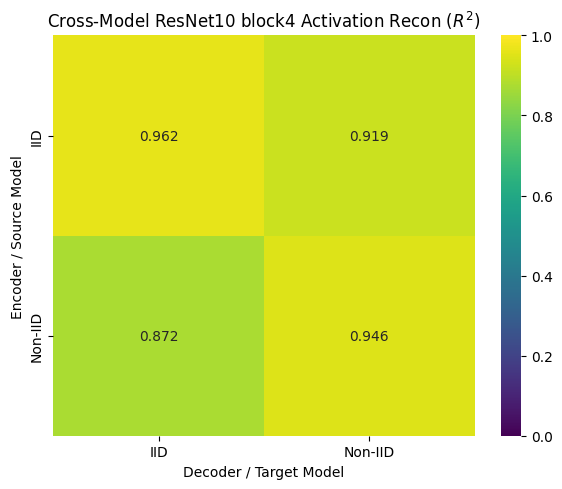

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n===========================================")
print("UNIVERSAL SAE (USAE) TRAINING (FOR RESNET10 BLOCK4)")
print("===========================================\n")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class UniversalSAE(nn.Module):
    """
    Universal Sparse Autoencoder (USAE)
    Learns a shared concept space Z across M different models.
    """
    def __init__(self, num_models, input_dim, num_concepts, top_k=32):
        super().__init__()
        self.num_models = num_models
        self.input_dim = input_dim
        self.num_concepts = num_concepts
        self.top_k = top_k

        # M Encoders
        self.W_enc = nn.ParameterList([
            nn.Parameter(torch.randn(input_dim, num_concepts) / (input_dim**0.5))
            for _ in range(num_models)
        ])
        self.b_pre = nn.ParameterList([
            nn.Parameter(torch.zeros(input_dim))
            for _ in range(num_models)
        ])

        # Batch Norm per model (following Appendix A.1)
        self.bn = nn.ModuleList([
            nn.BatchNorm1d(num_concepts)
            for _ in range(num_models)
        ])

        # M Decoders
        self.D = nn.ParameterList([
            nn.Parameter(torch.randn(num_concepts, input_dim) / (num_concepts**0.5))
            for _ in range(num_models)
        ])

    def encode(self, x, model_idx):
        # Apply pre-bias and encode
        h = (x - self.b_pre[model_idx]) @ self.W_enc[model_idx]
        # BatchNorm and ReLU
        h = F.relu(self.bn[model_idx](h))

        # TopK Sparsity Enforcement
        top_vals, top_idx = torch.topk(h, self.top_k, dim=-1)
        z = torch.zeros_like(h)
        z.scatter_(-1, top_idx, top_vals)
        return z

    def decode(self, z, model_idx):
        return z @ self.D[model_idx]


min_size = min(len(activations_iid), len(activations_niid))

# Subsample: Increased to 40k since ResNet10 spatial dimensions are smaller, saving VRAM
subset_size = min(40000, min_size)
A_iid_t = activations_iid[:subset_size].to(device)
A_niid_t = activations_niid[:subset_size].to(device)

dataset = TensorDataset(A_iid_t, A_niid_t)
# Increased batch size for smoother SAE gradients
dataloader = DataLoader(dataset, batch_size=1024, shuffle=True)

input_dim = A_iid_t.shape[-1] # Expected to be 256 for ResNet10 block4
expansion_factor = 8          # 8x overcomplete (Yields 2048 concepts)
num_concepts = input_dim * expansion_factor
top_k = 32                    # Hardcoded Top-K (Standard for SAEs of this size)

usae = UniversalSAE(
    num_models=2,
    input_dim=input_dim,
    num_concepts=num_concepts,
    top_k=top_k
).to(device)

# Using a single global optimizer ensures that ALL decoders update
optimizer = torch.optim.Adam(usae.parameters(), lr=1e-3)

num_epochs = 300
print(f"Training Universal SAE on block4 features (Dim={input_dim}).")
print(f"Shared Concepts: {num_concepts} | TopK: {top_k} | Epochs: {num_epochs}")

usae.train()
for epoch in range(num_epochs):
    total_loss = 0.0
    for batch in dataloader:
        A_batch = batch
        i = random.randint(0, usae.num_models - 1)

        optimizer.zero_grad()
        Z = usae.encode(A_batch[i], i)

        loss = 0.0
        for j in range(usae.num_models):
            A_hat_j = usae.decode(Z, j)
            # F.mse_loss is much more numerically stable for backprop than torch.norm (Frobenius)
            loss += F.mse_loss(A_hat_j, A_batch[j])

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:03d}/{num_epochs} - Total Universal Loss (MSE): {total_loss/len(dataloader):.4f}")

print("USAE training completed.")
print("\n[Evaluating Cross-Model Activation Reconstruction (R^2 Score)]")

def calculate_r2(true_A, recon_A):
    ss_res = ((true_A - recon_A)**2).sum()
    ss_tot = ((true_A - true_A.mean(dim=0))**2).sum()
    return max(0.0, (1 - ss_res / ss_tot).item())

usae.eval()
with torch.no_grad():
    labels = ["IID", "Non-IID"]
    A_eval = [A_iid_t, A_niid_t]

    # Store R^2 matrix [Encoder_i, Decoder_j]
    r2_matrix = np.zeros((2, 2))

    for i in range(2):
        Z = usae.encode(A_eval[i], i)
        for j in range(2):
            A_hat = usae.decode(Z, j)
            r2_matrix[i, j] = calculate_r2(A_eval[j], A_hat)

    print(f"{'Encoder':<15} | {'Decoder':<15} | R^2 Score")
    print("-" * 45)
    for i in range(2):
        for j in range(2):
            recons_type = "Self-Recon" if i == j else "Cross-Recon"
            print(f"{labels[i]:<15} | {labels[j]:<15} | {r2_matrix[i,j]:.4f} ({recons_type})")

print("\n[Checking Sparsity Level]")

with torch.no_grad():
    Z_iid = usae.encode(A_iid_t, 0)
    Z_niid = usae.encode(A_niid_t, 1)

    iid_active = (Z_iid > 0).float().sum(dim=1).mean().item()
    niid_active = (Z_niid > 0).float().sum(dim=1).mean().item()

print(f"Expected active concepts (TopK): {top_k}")
print(f"IID avg active concepts: {iid_active:.2f}")
print(f"Non-IID avg active concepts: {niid_active:.2f}")

# Visualizing the R2 Matrix
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(r2_matrix, annot=True, fmt=".3f", cmap="viridis",
            xticklabels=labels, yticklabels=labels, ax=ax, vmin=0, vmax=1)
ax.set_title("Cross-Model ResNet10 block4 Activation Recon ($R^2$)")
ax.set_xlabel("Decoder / Target Model")
ax.set_ylabel("Encoder / Source Model")
plt.tight_layout()
plt.show()

Total Active Concepts: 1399 / 2048
Concepts Unique to IID Model: 507
Concepts Unique to Non-IID Model: 414


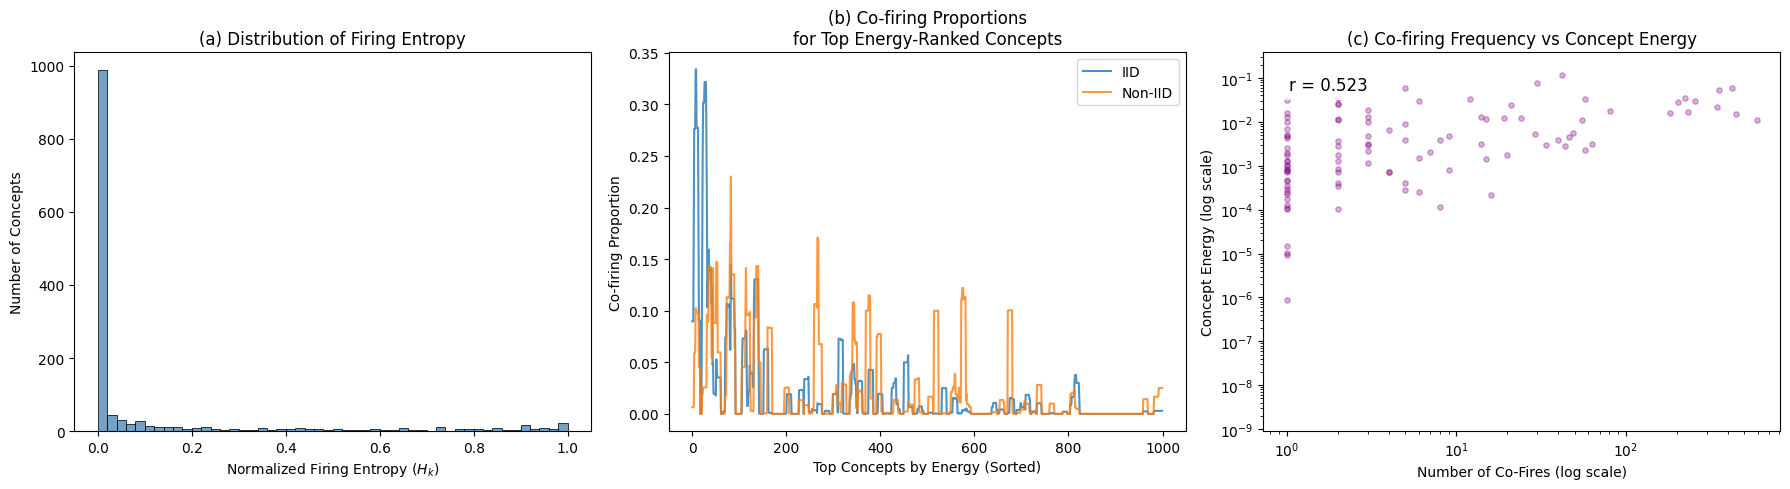

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

usae.eval()
with torch.no_grad():
    Z_iid = usae.encode(A_iid_t, 0)
    Z_niid = usae.encode(A_niid_t, 1)
    fires_iid = (Z_iid > 0).float()
    fires_niid = (Z_niid > 0).float()
    co_fires = fires_iid * fires_niid

    total_iid = fires_iid.sum(dim=0)
    total_niid = fires_niid.sum(dim=0)
    total_co_fires = co_fires.sum(dim=0)
    total_any_fires = total_iid + total_niid
    active_mask = total_any_fires > 0
    p_iid = total_iid / (total_any_fires + 1e-9)
    p_niid = total_niid / (total_any_fires + 1e-9)
    p_iid_active = p_iid[active_mask]
    p_niid_active = p_niid[active_mask]
    entropy_active = -(p_iid_active * torch.log2(p_iid_active + 1e-9) +
                       p_niid_active * torch.log2(p_niid_active + 1e-9))

    def get_concept_energies(Z, decoder_weights):
        expected_Z = Z.mean(dim=0)
        contributions = expected_Z.unsqueeze(1) * decoder_weights
        return torch.norm(contributions, p=2, dim=1)**2

    energy_iid = get_concept_energies(Z_iid, usae.D[0])
    energy_niid = get_concept_energies(Z_niid, usae.D[1])
    avg_energy = (energy_iid + energy_niid) / 2.0

    cfp_iid = total_co_fires / (total_iid + 1e-9)
    cfp_niid = total_co_fires / (total_niid + 1e-9)

    sorted_indices = torch.argsort(avg_energy, descending=True)
    top_k_plot = min(1000, len(sorted_indices))

    sorted_cfp_iid = cfp_iid[sorted_indices][:top_k_plot].cpu().numpy()
    sorted_cfp_niid = cfp_niid[sorted_indices][:top_k_plot].cpu().numpy()

    unique_to_iid = torch.where((total_iid > 10) & (p_iid > 0.95))[0]
    unique_to_niid = torch.where((total_niid > 10) & (p_niid > 0.95))[0]

    print(f"Total Active Concepts: {active_mask.sum().item()} / {Z_iid.shape[1]}")
    print(f"Concepts Unique to IID Model: {len(unique_to_iid)}")
    print(f"Concepts Unique to Non-IID Model: {len(unique_to_niid)}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(entropy_active.cpu().numpy(), bins=50, ax=axes[0], color='steelblue')
axes[0].set_title("(a) Distribution of Firing Entropy")
axes[0].set_xlabel("Normalized Firing Entropy ($H_k$)")
axes[0].set_ylabel("Number of Concepts")
axes[0].set_xlim(-0.05, 1.05)
def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    return np.convolve(y, box, mode='same')

axes[1].plot(smooth(sorted_cfp_iid, 10), label='IID', alpha=0.8)
axes[1].plot(smooth(sorted_cfp_niid, 10), label='Non-IID', alpha=0.8)
axes[1].set_title("(b) Co-firing Proportions\nfor Top Energy-Ranked Concepts")
axes[1].set_xlabel("Top Concepts by Energy (Sorted)")
axes[1].set_ylabel("Co-firing Proportion")
axes[1].legend()

x_data = total_co_fires[active_mask].cpu().numpy()
y_data = avg_energy[active_mask].cpu().numpy()

axes[2].scatter(x_data, y_data, alpha=0.3, s=15, color='purple')
axes[2].set_title("(c) Co-firing Frequency vs Concept Energy")
axes[2].set_xlabel("Number of Co-Fires (log scale)")
axes[2].set_ylabel("Concept Energy (log scale)")
axes[2].set_xscale('log')
axes[2].set_yscale('log')

valid = (x_data > 0) & (y_data > 0)
if valid.sum() > 1:
    r = np.corrcoef(np.log10(x_data[valid]), np.log10(y_data[valid]))[0, 1]
    axes[2].text(0.05, 0.9, f"r = {r:.3f}", transform=axes[2].transAxes, fontsize=12,
                 bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.tight_layout()
plt.show()

In [8]:
import torch
from tqdm import tqdm
from einops import rearrange
import numpy as np

# Ensure device is defined
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_accuracy(model, dataloader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, predicted = torch.max(outputs.data, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()
    return correct / total

def evaluate_usae_performance(source_idx, target_idx, source_model, target_model, usae, dataloader, mask=None):
    source_model.eval()
    target_model.eval()
    usae.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)

            # 1. Source feature extraction (ResNet10 up to block4)
            feat = source_model.conv1(x)
            feat = source_model.bn1(feat)
            feat = source_model.relu(feat)
            feat = source_model.maxpool(feat)

            feat = source_model.block1(feat)
            feat = source_model.block2(feat)
            feat = source_model.block3(feat)
            feat = source_model.block4(feat)

            # Flatten spatial dimensions for USAE
            b, c, h, w = feat.shape
            feat_flat = rearrange(feat, 'b c h w -> (b h w) c')

            # 2. Encode into shared concept space
            Z = usae.encode(feat_flat, source_idx)

            # Apply masking (isolate shared vs unique concepts)
            if mask is not None:
                Z = Z * mask

            # 3. Decode into target model's activation space
            recon_flat = usae.decode(Z, target_idx)

            # Reshape back to spatial dimensions
            recon_feat = rearrange(recon_flat, '(b h w) c -> b c h w', b=b, h=h, w=w).contiguous()

            # 4. Target forward pass completion (ResNet10 after block4)
            out = target_model.avgpool(recon_feat)
            out = torch.flatten(out, 1)
            logits = target_model.fc(out)

            # Calculate accuracy
            _, predicted = torch.max(logits.data, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

    return correct / total

# ==========================================
# Run Evaluation
# ==========================================

usae.eval()
with torch.no_grad():
    Z_iid = usae.encode(A_iid_t, 0)
    Z_niid = usae.encode(A_niid_t, 1)

    # Identify which concepts ever fire (>0) for each distribution
    active_iid = (Z_iid > 0).any(dim=0)
    active_niid = (Z_niid > 0).any(dim=0)

    # Create binary masks for different concept families
    mask_shared = (active_iid & active_niid).float()
    mask_iid_only = (active_iid & ~active_niid).float()
    mask_niid_only = (~active_iid & active_niid).float()

families = [
    ("Shared Concepts", mask_shared),
    ("IID-Unique Concepts", mask_iid_only),
    ("Non-IID-Unique Concepts", mask_niid_only)
]

print("Calculating Baselines...")
acc_iid_base = get_accuracy(model_iid, test_loader_iid)
acc_niid_base = get_accuracy(model_niid, test_loader_niid)

print("\n" + "="*85)
print(f"{'Concept Family':<25} | {'Source':<8} -> {'Target':<8} | Accuracy | % of Base")
print("-" * 85)

for name, mask in families:
    active_count = int(mask.sum().item())

    # Self-Reconstruction Performance
    acc_ii = evaluate_usae_performance(0, 0, model_iid, model_iid, usae, test_loader_iid, mask)
    acc_nn = evaluate_usae_performance(1, 1, model_niid, model_niid, usae, test_loader_niid, mask)

    # Cross-Model Stitching Performance
    acc_in = evaluate_usae_performance(0, 1, model_iid, model_niid, usae, test_loader_iid, mask)
    acc_ni = evaluate_usae_performance(1, 0, model_niid, model_iid, usae, test_loader_niid, mask)

    print(f"{name:<25} ({active_count:4d} concepts)")
    print(f"{'':<25} | {'IID':<8} -> {'IID':<8} | {acc_ii:.4f}   | {(acc_ii/acc_iid_base)*100:6.1f}%")
    print(f"{'':<25} | {'NIID':<8} -> {'NIID':<8} | {acc_nn:.4f}   | {(acc_nn/acc_niid_base)*100:6.1f}%")
    print(f"{'':<25} | {'IID':<8} -> {'NIID':<8} | {acc_in:.4f}   | {(acc_in/acc_niid_base)*100:6.1f}%") # Evaluated against target base
    print(f"{'':<25} | {'NIID':<8} -> {'IID':<8} | {acc_ni:.4f}   | {(acc_ni/acc_iid_base)*100:6.1f}%")  # Evaluated against target base
    print("-" * 85)

print(f"{'Full USAE (All Concepts)':<25}")
acc_full_in = evaluate_usae_performance(0, 1, model_iid, model_niid, usae, test_loader_iid)
acc_full_ni = evaluate_usae_performance(1, 0, model_niid, model_iid, usae, test_loader_niid)
print(f"{'':<25} | {'IID':<8} -> {'NIID':<8} | {acc_full_in:.4f}   | {(acc_full_in/acc_niid_base)*100:6.1f}%")
print(f"{'':<25} | {'NIID':<8} -> {'IID':<8} | {acc_full_ni:.4f}   | {(acc_full_ni/acc_iid_base)*100:6.1f}%")
print("="*85)

Calculating Baselines...

Concept Family            | Source   -> Target   | Accuracy | % of Base
-------------------------------------------------------------------------------------
Shared Concepts           ( 421 concepts)
                          | IID      -> IID      | 0.9165   |   92.0%
                          | NIID     -> NIID     | 0.5629   |  133.0%
                          | IID      -> NIID     | 0.6102   |  144.2%
                          | NIID     -> IID      | 0.9755   |   97.9%
-------------------------------------------------------------------------------------
IID-Unique Concepts       ( 556 concepts)
                          | IID      -> IID      | 0.9961   |  100.0%
                          | NIID     -> NIID     | 0.1911   |   45.1%
                          | IID      -> NIID     | 0.6612   |  156.2%
                          | NIID     -> IID      | 0.1965   |   19.7%
-------------------------------------------------------------------------------------


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class LinearProbe(nn.Module):
    def __init__(self, input_dim=256, num_classes=5):
        super().__init__()
        self.fc = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.fc(x)


# Modified to extract features at a specific target_block
def get_resnet_features(model, x, target_block):
    with torch.no_grad():
        x = model.conv1(x)
        x = model.bn1(x)
        x = model.relu(x)
        x = model.maxpool(x)

        if target_block >= 1: x = model.block1(x)
        if target_block >= 2: x = model.block2(x)
        if target_block >= 3: x = model.block3(x)
        if target_block >= 4: x = model.block4(x) # 'final' corresponds to block4

        x = model.avgpool(x)
        x = torch.flatten(x, 1)
    return x


def filter_dataset(dataset):
    data = []
    labels = []

    for img, label in dataset:
        if label < 5:
            data.append(img)
            labels.append(label)

    data = torch.stack(data)
    labels = torch.tensor(labels)

    return TensorDataset(data, labels)


# Modified to accept target_block
def extract_features(backbone, loader, target_block):
    backbone.eval()

    all_features = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            features = get_resnet_features(backbone, images, target_block) # Pass target_block

            all_features.append(features.cpu())
            all_labels.append(labels)

    features = torch.cat(all_features)
    labels = torch.cat(all_labels)

    return TensorDataset(features, labels)


def train_probe(feature_loader, input_dim, epochs=100):

    probe = LinearProbe(input_dim=input_dim, num_classes=5).to(device)

    optimizer = optim.Adam(probe.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):

        probe.train()

        total_loss = 0
        correct = 0
        total = 0

        for features, labels in feature_loader:

            features = features.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            logits = probe(features)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            _, predicted = torch.max(logits, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        print(
            f"Epoch {epoch+1:02d}: "
            f"Loss = {total_loss/len(feature_loader):.4f} | "
            f"Acc = {correct/total:.4f}"
        )

    return probe


def evaluate_probe(probe, feature_loader):

    probe.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for features, labels in feature_loader:

            features = features.to(device)
            labels = labels.to(device)

            logits = probe(features)

            _, predicted = torch.max(logits, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])


raw_train = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

raw_test = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


train_dataset = filter_dataset(raw_train)
test_dataset = filter_dataset(raw_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


# Define the layers to extract features from
layer_map = {"block2": 2, "block3": 3, "final": 4} # Map layer names to block_idx

iid_train = {}
iid_test = {}
niid_train = {}
niid_test = {}

# Populate the dictionaries with features for each layer
for layer_name, block_idx in layer_map.items():
    print(f"Extracting IID backbone features for {layer_name} (Block {block_idx})...")
    iid_train[layer_name] = extract_features(model_iid, train_loader, block_idx)
    iid_test[layer_name] = extract_features(model_iid, test_loader, block_idx)

    print(f"Extracting NIID backbone features for {layer_name} (Block {block_idx})...")
    niid_train[layer_name] = extract_features(model_niid, train_loader, block_idx)
    niid_test[layer_name] = extract_features(model_niid, test_loader, block_idx)

Extracting IID backbone features for block2 (Block 2)...
Extracting NIID backbone features for block2 (Block 2)...
Extracting IID backbone features for block3 (Block 3)...
Extracting NIID backbone features for block3 (Block 3)...
Extracting IID backbone features for final (Block 4)...
Extracting NIID backbone features for final (Block 4)...


In [10]:
def run_layer_probes(name, train_layer_datasets, own_test_datasets, cross_test_datasets, cross_name, epochs=100):
    print(f"\n{'='*70}")
    print(f"  Backbone: {name}")
    print(f"{'='*70}")
    results = {}
    for layer in ["block2", "block3", "final"]:
        input_dim = train_layer_datasets[layer].tensors[0].shape[1]
        print(f"\n  [Layer: {layer}]  feature_dim={input_dim}")

        train_loader      = DataLoader(train_layer_datasets[layer],  batch_size=128, shuffle=True)
        own_test_loader   = DataLoader(own_test_datasets[layer],     batch_size=128, shuffle=False)
        cross_test_loader = DataLoader(cross_test_datasets[layer],   batch_size=128, shuffle=False)

        probe = train_probe(train_loader, input_dim=input_dim, epochs=10)

        own_acc   = evaluate_probe(probe, own_test_loader)
        cross_acc = evaluate_probe(probe, cross_test_loader)

        results[layer] = {"own": own_acc, "cross": cross_acc}
        print(f"  → Test Acc [{layer}]  {name} features: {own_acc:.4f}  |  {cross_name} features: {cross_acc:.4f}")

    return results


iid_results  = run_layer_probes("IID",  iid_train,  iid_test,  niid_test, cross_name="NIID")
niid_results = run_layer_probes("NIID", niid_train, niid_test, iid_test,  cross_name="IID")

print(f"\n{'='*70}")
print(f"  Probe trained on →    IID backbone          NIID backbone")
print(f"  Eval on ↓          own      cross        own      cross")
print(f"  {'(IID test)':18s} {'(NIID test)':12s} {'(NIID test)':12s} {'(IID test)':12s}")
print(f"{'-'*70}")
for layer in ["block2", "block3", "final"]:
    iid_own   = iid_results[layer]["own"]
    iid_cross = iid_results[layer]["cross"]
    niid_own  = niid_results[layer]["own"]
    niid_cross= niid_results[layer]["cross"]
    print(f"  {layer:<16}  {iid_own:.4f}    {iid_cross:.4f}      {niid_own:.4f}    {niid_cross:.4f}")
print(f"{'='*70}")


  Backbone: IID

  [Layer: block2]  feature_dim=128
Epoch 01: Loss = 1.4997 | Acc = 0.5423
Epoch 02: Loss = 1.2969 | Acc = 0.7916
Epoch 03: Loss = 1.1470 | Acc = 0.8441
Epoch 04: Loss = 1.0291 | Acc = 0.8645
Epoch 05: Loss = 0.9343 | Acc = 0.8856
Epoch 06: Loss = 0.8559 | Acc = 0.9036
Epoch 07: Loss = 0.7901 | Acc = 0.9168
Epoch 08: Loss = 0.7323 | Acc = 0.9240
Epoch 09: Loss = 0.6840 | Acc = 0.9269
Epoch 10: Loss = 0.6420 | Acc = 0.9307
  → Test Acc [block2]  IID features: 0.9445  |  NIID features: 0.2769

  [Layer: block3]  feature_dim=192
Epoch 01: Loss = 1.3402 | Acc = 0.6589
Epoch 02: Loss = 0.8268 | Acc = 0.9869
Epoch 03: Loss = 0.5321 | Acc = 0.9920
Epoch 04: Loss = 0.3677 | Acc = 0.9932
Epoch 05: Loss = 0.2693 | Acc = 0.9938
Epoch 06: Loss = 0.2081 | Acc = 0.9941
Epoch 07: Loss = 0.1669 | Acc = 0.9942
Epoch 08: Loss = 0.1372 | Acc = 0.9943
Epoch 09: Loss = 0.1161 | Acc = 0.9944
Epoch 10: Loss = 0.0999 | Acc = 0.9945
  → Test Acc [block3]  IID features: 0.9953  |  NIID features

In [11]:
class AffineAdapter(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.map = nn.Linear(dim, dim)
        nn.init.eye_(self.map.weight)
        nn.init.zeros_(self.map.bias)

    def forward(self, x):
        return self.map(x)


def run_affine_adapter(iid_train_ds, niid_train_ds,
                       iid_test_ds,  niid_test_ds,
                       input_dim, adapter_epochs=200, probe_epochs=100):

    iid_feats  = iid_train_ds.tensors[0].to(device)
    niid_feats = niid_train_ds.tensors[0].to(device)

    adapter   = AffineAdapter(input_dim).to(device)
    opt       = optim.Adam(adapter.parameters(), lr=1e-3, weight_decay=1e-5)
    mse       = nn.MSELoss()

    adapt_ds     = TensorDataset(niid_feats.cpu(), iid_feats.cpu())
    adapt_loader = DataLoader(adapt_ds, batch_size=256, shuffle=True)

    print("  Training affine adapter (NIID → IID space)...")
    for epoch in range(adapter_epochs):
        adapter.train()
        total = 0.0
        for niid_b, iid_b in adapt_loader:
            niid_b, iid_b = niid_b.to(device), iid_b.to(device)
            opt.zero_grad()
            loss = mse(adapter(niid_b), iid_b)
            loss.backward()
            opt.step()
            total += loss.item()
        if (epoch + 1) % 40 == 0 or epoch == 0:
            print(f"    adapter ep {epoch+1:03d}  mse={total/len(adapt_loader):.6f}")

    iid_train_loader = DataLoader(iid_train_ds, batch_size=128, shuffle=True)
    print("\n  Training probe on IID features...")
    probe = train_probe(iid_train_loader, input_dim=input_dim, epochs=probe_epochs)

    adapter.eval()
    niid_test_feats, niid_test_lbls = niid_test_ds.tensors
    with torch.no_grad():
        niid_adapted = adapter(niid_test_feats.to(device)).cpu()
    niid_adapted_ds = TensorDataset(niid_adapted, niid_test_lbls)

    iid_test_loader          = DataLoader(iid_test_ds,    batch_size=128, shuffle=False)
    niid_adapted_test_loader = DataLoader(niid_adapted_ds, batch_size=128, shuffle=False)

    acc_iid  = evaluate_probe(probe, iid_test_loader)
    acc_niid = evaluate_probe(probe, niid_adapted_test_loader)
    print(f"\n  Affine adapter probe → IID test: {acc_iid:.4f}  |  NIID test (adapted): {acc_niid:.4f}")
    return probe, adapter

for layer in ["block2", "block3", "final"]:
    dim = iid_train[layer].tensors[0].shape[1]
    print(f"\n{'='*70}")
    print(f"  Layer: {layer}  dim={dim}")
    print(f"{'='*70}")
    run_affine_adapter(iid_train[layer], niid_train[layer],
                       iid_test[layer],  niid_test[layer],
                       input_dim=dim)


  Layer: block2  dim=128
  Training affine adapter (NIID → IID space)...
    adapter ep 001  mse=0.024048
    adapter ep 040  mse=0.006292
    adapter ep 080  mse=0.006187
    adapter ep 120  mse=0.006170
    adapter ep 160  mse=0.006168
    adapter ep 200  mse=0.006166

  Training probe on IID features...
Epoch 01: Loss = 1.5321 | Acc = 0.3897
Epoch 02: Loss = 1.3286 | Acc = 0.7286
Epoch 03: Loss = 1.1767 | Acc = 0.8085
Epoch 04: Loss = 1.0590 | Acc = 0.8446
Epoch 05: Loss = 0.9612 | Acc = 0.8796
Epoch 06: Loss = 0.8801 | Acc = 0.8971
Epoch 07: Loss = 0.8113 | Acc = 0.9087
Epoch 08: Loss = 0.7525 | Acc = 0.9166
Epoch 09: Loss = 0.7025 | Acc = 0.9244
Epoch 10: Loss = 0.6585 | Acc = 0.9289
Epoch 11: Loss = 0.6190 | Acc = 0.9306
Epoch 12: Loss = 0.5840 | Acc = 0.9341
Epoch 13: Loss = 0.5519 | Acc = 0.9356
Epoch 14: Loss = 0.5243 | Acc = 0.9371
Epoch 15: Loss = 0.4977 | Acc = 0.9388
Epoch 16: Loss = 0.4740 | Acc = 0.9401
Epoch 17: Loss = 0.4521 | Acc = 0.9416
Epoch 18: Loss = 0.4325 | Ac


[block2]  N=30596  D=128
  Computing full principal angle curve...
  Checkpoint        k   mean cosine
  -----------------------------------
  top-10           10        0.2896
  top-25%          32        0.4643
  top-50%          64        0.6441
  top-75%          96        0.8075
  top-100%        128        1.0000

[block3]  N=30596  D=192
  Computing full principal angle curve...
  Checkpoint        k   mean cosine
  -----------------------------------
  top-10           10        0.1962
  top-25%          48        0.4460
  top-50%          96        0.6392
  top-75%         144        0.8016
  top-100%        192        1.0000

[final]  N=30596  D=256
  Computing full principal angle curve...
  Checkpoint        k   mean cosine
  -----------------------------------
  top-10           10        0.2385
  top-25%          64        0.4484
  top-50%         128        0.6365
  top-75%         192        0.8062
  top-100%        256        1.0000


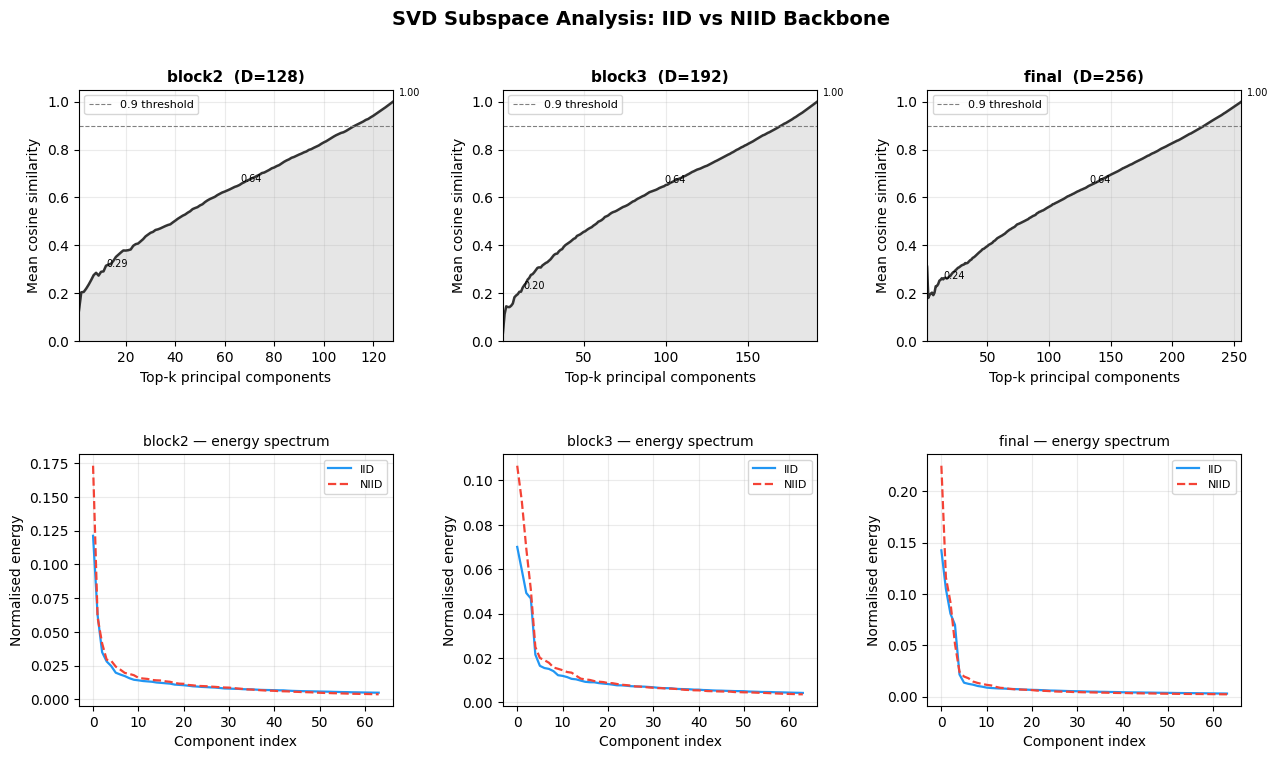


Saved: svd_subspace_analysis.png

  Layer         top-10   top-25%   top-50%   top-100%
  -------------------------------------------------------
  block2        0.2896    0.4643    0.6441     1.0000
  block3        0.1962    0.4460    0.6392     1.0000
  final         0.2385    0.4484    0.6365     1.0000


In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def get_principal_components(feats):
    """
    Centre features and return (S, V) from thin SVD of the feature matrix.
    feats : (N, D)
    S     : (min(N,D),)   singular values = sqrt of explained variance
    V     : (min(N,D), D) rows are principal directions in feature space
    """
    feats = feats - feats.mean(0)
    _, S, V = torch.linalg.svd(feats, full_matrices=False)
    return S, V


def principal_angle_cosines(V_a, V_b, k):
    """
    Cosines of the k principal angles between the top-k subspaces of A and B.
    = singular values of  V_a[:k] @ V_b[:k].T   (a k×k matrix)
    1.0 → perfectly aligned component, 0.0 → orthogonal
    """
    cos = torch.linalg.svdvals(V_a[:k] @ V_b[:k].T)
    return cos.clamp(0.0, 1.0)


def subspace_alignment_curve(V_a, V_b):
    """
    Mean cosine similarity of top-k subspace for every k from 1 to D.
    Returns a (D,) numpy array — the full alignment curve.
    """
    D = V_a.shape[1]
    k_max = min(V_a.shape[0], V_b.shape[0], D)
    curve = np.empty(k_max)
    for k in range(1, k_max + 1):
        curve[k - 1] = principal_angle_cosines(V_a, V_b, k).mean().item()
    return curve


def analyze_layer(layer_name, iid_train_ds, niid_train_ds, device):
    iid_feats  = iid_train_ds.tensors[0].to(device).float()
    niid_feats = niid_train_ds.tensors[0].to(device).float()

    N, D = iid_feats.shape
    assert iid_feats.shape == niid_feats.shape, "Shape mismatch"
    print(f"\n[{layer_name}]  N={N}  D={D}")

    S_iid,  V_iid  = get_principal_components(iid_feats)
    S_niid, V_niid = get_principal_components(niid_feats)

    print("  Computing full principal angle curve...")
    curve = subspace_alignment_curve(V_iid, V_niid)

    checkpoints = {
        "top-10":    min(10, D),
        "top-25%":   max(1, D // 4),
        "top-50%":   max(1, D // 2),
        "top-75%":   max(1, 3 * D // 4),
        "top-100%":  D,
    }
    print(f"  {'Checkpoint':<12}  {'k':>5}  {'mean cosine':>12}")
    print(f"  {'-'*35}")
    for label, k in checkpoints.items():
        k = min(k, len(curve))
        print(f"  {label:<12}  {k:>5}  {curve[k-1]:>12.4f}")

    S_iid_norm  = (S_iid  / S_iid.sum()).cpu().numpy()
    S_niid_norm = (S_niid / S_niid.sum()).cpu().numpy()

    return {
        "layer":       layer_name,
        "D":           D,
        "curve":       curve,
        "S_iid":       S_iid_norm,
        "S_niid":      S_niid_norm,
        "checkpoints": {k: curve[v - 1] for k, v in checkpoints.items()},
    }

layers  = ["block2", "block3", "final"]
results = {
    lay: analyze_layer(lay, iid_train[lay], niid_train[lay], device)
    for lay in layers
}



fig = plt.figure(figsize=(15, 8))
fig.suptitle("SVD Subspace Analysis: IID vs NIID Backbone", fontsize=14, fontweight="bold")
gs = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.35)

colors = {"iid": "#2196F3", "niid": "#F44336", "curve": "#333333"}

for col, lay in enumerate(layers):
    res = results[lay]
    D   = res["D"]

    ax_top = fig.add_subplot(gs[0, col])
    xs = np.arange(1, len(res["curve"]) + 1)
    ax_top.plot(xs, res["curve"], color=colors["curve"], lw=1.8)
    ax_top.axhline(0.9, color="grey", lw=0.8, ls="--", label="0.9 threshold")
    ax_top.fill_between(xs, res["curve"], alpha=0.12, color=colors["curve"])
    ax_top.set_title(f"{lay}  (D={D})", fontsize=11, fontweight="bold")
    ax_top.set_xlabel("Top-k principal components")
    ax_top.set_ylabel("Mean cosine similarity")
    ax_top.set_ylim(0, 1.05)
    ax_top.set_xlim(1, D)
    ax_top.legend(fontsize=8)
    ax_top.grid(True, alpha=0.25)

    # Annotate key values
    for label, val in res["checkpoints"].items():
        k_idx = {"top-10": min(10, D), "top-50%": D // 2, "top-100%": D}.get(label)
        if k_idx:
            ax_top.annotate(f"{val:.2f}", xy=(k_idx, val),
                            xytext=(4, 4), textcoords="offset points",
                            fontsize=7, color="black")

    ax_bot = fig.add_subplot(gs[1, col])
    n_show = min(D, 64)    # show up to 64 components to keep it readable
    ax_bot.plot(res["S_iid"][:n_show],  color=colors["iid"],  lw=1.6, label="IID")
    ax_bot.plot(res["S_niid"][:n_show], color=colors["niid"], lw=1.6, label="NIID", ls="--")
    ax_bot.set_title(f"{lay} — energy spectrum", fontsize=10)
    ax_bot.set_xlabel("Component index")
    ax_bot.set_ylabel("Normalised energy")
    ax_bot.legend(fontsize=8)
    ax_bot.grid(True, alpha=0.25)

plt.savefig("svd_subspace_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: svd_subspace_analysis.png")



print(f"\n{'='*65}")
print(f"  {'Layer':<10}  {'top-10':>8}  {'top-25%':>8}  {'top-50%':>8}  {'top-100%':>9}")
print(f"  {'-'*55}")
for lay in layers:
    cp = results[lay]["checkpoints"]
    print(f"  {lay:<10}  {cp['top-10']:>8.4f}  {cp['top-25%']:>8.4f}"
          f"  {cp['top-50%']:>8.4f}  {cp['top-100%']:>9.4f}")
print(f"{'='*65}")

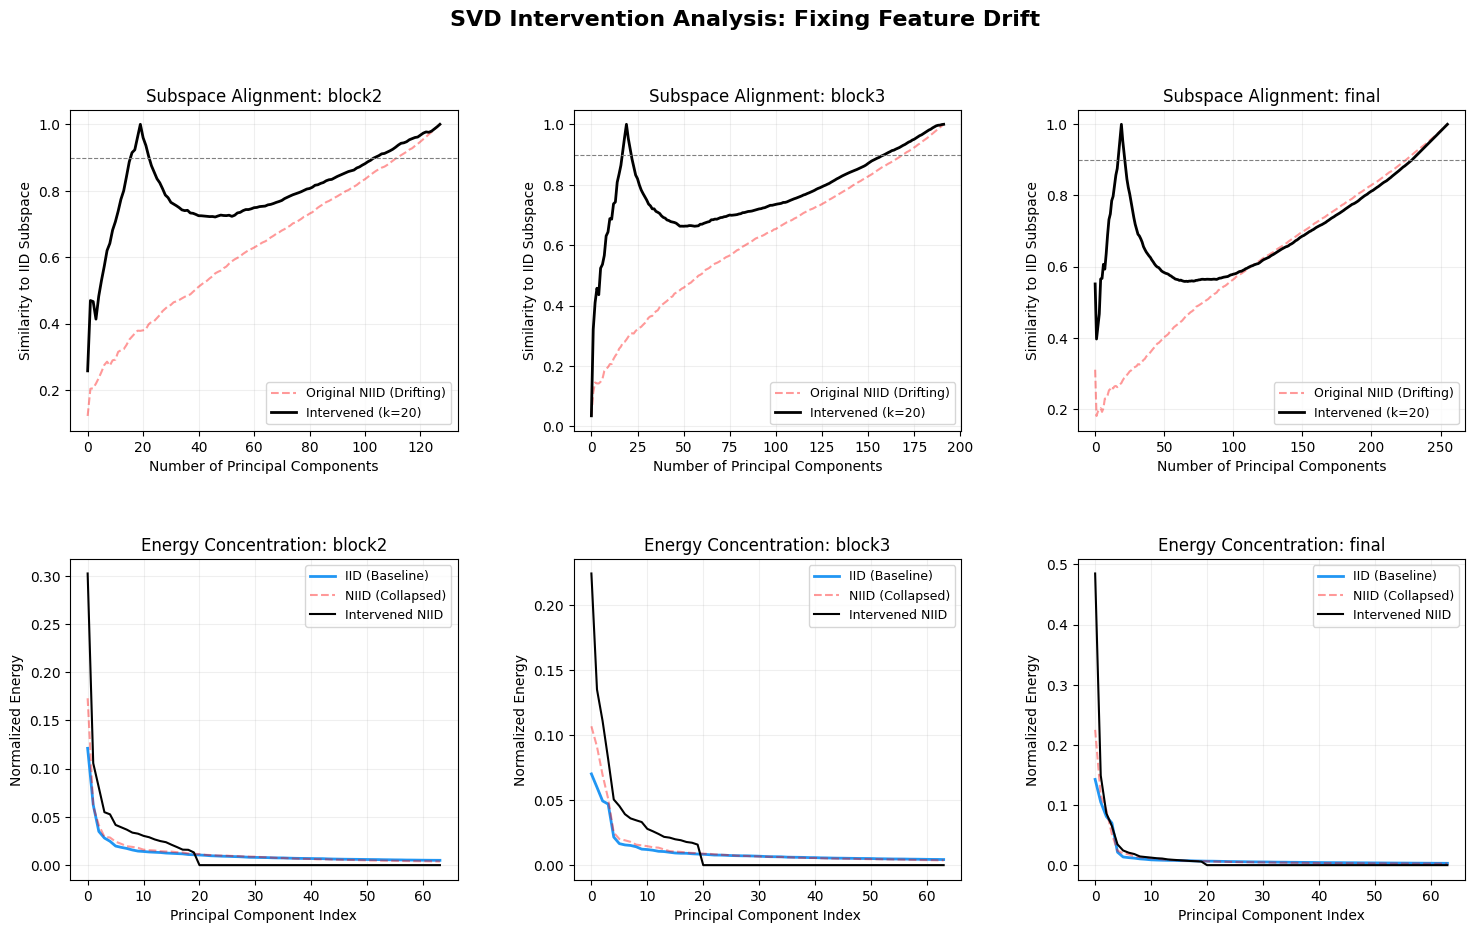

In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def get_principal_components(feats):
    # Center the data to find directions of maximum variance
    feats = feats - feats.mean(0)
    _, S, V = torch.linalg.svd(feats, full_matrices=False)
    return S, V

def principal_angle_cosines(V_a, V_b, k):
    # Calculates how much the top-k subspaces 'overlap'
    cos = torch.linalg.svdvals(V_a[:k] @ V_b[:k].T)
    return cos.clamp(0.0, 1.0)

def subspace_alignment_curve(V_a, V_b):
    D = V_a.shape[1]
    k_max = min(V_a.shape[0], V_b.shape[0], D)
    curve = np.empty(k_max)
    for k in range(1, k_max + 1):
        curve[k - 1] = principal_angle_cosines(V_a, V_b, k).mean().item()
    return curve

def apply_subspace_intervention(niid_feats, V_iid, k):
    # Forced Projection: Keep only the directions used by the IID model
    V_iid_k = V_iid[:k, :]
    projected_coords = niid_feats @ V_iid_k.T
    intervened_feats = projected_coords @ V_iid_k
    return intervened_feats

def analyze_layer(layer_name, iid_train_ds, niid_train_ds, device, k_intv=32):
    iid_feats = iid_train_ds.tensors[0].to(device).float()
    niid_feats_raw = niid_train_ds.tensors[0].to(device).float()

    # 1. Baseline SVD (IID)
    S_iid, V_iid = get_principal_components(iid_feats)

    # 2. Raw NIID SVD
    S_niid_raw, V_niid_raw = get_principal_components(niid_feats_raw)

    # 3. Apply Intervention (Project NIID onto IID subspace)
    niid_feats_intv = apply_subspace_intervention(niid_feats_raw, V_iid, k_intv)
    S_niid_intv, V_niid_intv = get_principal_components(niid_feats_intv)

    # Calculate Alignment Curves
    curve_raw = subspace_alignment_curve(V_iid, V_niid_raw)
    curve_intv = subspace_alignment_curve(V_iid, V_niid_intv)

    return {
        "name": layer_name,
        "D": iid_feats.shape[1],
        "curve_raw": curve_raw,
        "curve_intv": curve_intv,
        "S_iid": (S_iid / S_iid.sum()).cpu().numpy(),
        "S_niid_raw": (S_niid_raw / S_niid_raw.sum()).cpu().numpy(),
        "S_niid_intv": (S_niid_intv / S_niid_intv.sum()).cpu().numpy(),
        "k_intv": k_intv
    }

# Execution
layers = ["block2", "block3", "final"]
results = [analyze_layer(l, iid_train[l], niid_train[l], device, k_intv=20) for l in layers]

# Plotting with explicit labels
fig = plt.figure(figsize=(18, 10))
fig.suptitle("SVD Intervention Analysis: Fixing Feature Drift", fontsize=16, fontweight="bold")
gs = gridspec.GridSpec(2, 3, hspace=0.4, wspace=0.3)

for i, res in enumerate(results):
    # TOP ROW: Alignment (The 'Language' Test)
    ax_top = fig.add_subplot(gs[0, i])
    ax_top.plot(res["curve_raw"], color="red", label="Original NIID (Drifting)", alpha=0.4, ls="--")
    ax_top.plot(res["curve_intv"], color="black", label=f"Intervened (k={res['k_intv']})", lw=2)
    ax_top.axhline(0.9, color="grey", lw=0.8, ls="--")

    ax_top.set_title(f"Subspace Alignment: {res['name']}")
    ax_top.set_ylabel("Similarity to IID Subspace")
    ax_top.set_xlabel("Number of Principal Components")
    ax_top.legend(loc="lower right", fontsize=9)
    ax_top.grid(alpha=0.2)

    # BOTTOM ROW: Energy Spectrum (The 'Focus' Test)
    ax_bot = fig.add_subplot(gs[1, i])
    n_view = 64
    ax_bot.plot(res["S_iid"][:n_view], color="#2196F3", label="IID (Baseline)", lw=2)
    ax_bot.plot(res["S_niid_raw"][:n_view], color="red", label="NIID (Collapsed)", alpha=0.4, ls="--")
    ax_bot.plot(res["S_niid_intv"][:n_view], color="black", label="Intervened NIID", lw=1.5)

    ax_bot.set_title(f"Energy Concentration: {res['name']}")
    ax_bot.set_ylabel("Normalized Energy")
    ax_bot.set_xlabel("Principal Component Index")
    ax_bot.legend(fontsize=9)
    ax_bot.grid(alpha=0.2)

plt.show()

Training IID probe for [block2]...
Epoch 01: Loss = 1.5605 | Acc = 0.3502
Epoch 02: Loss = 1.3478 | Acc = 0.6546
Epoch 03: Loss = 1.1929 | Acc = 0.7607
Epoch 04: Loss = 1.0708 | Acc = 0.8051
Epoch 05: Loss = 0.9730 | Acc = 0.8473
Epoch 06: Loss = 0.8920 | Acc = 0.8674
Epoch 07: Loss = 0.8238 | Acc = 0.8887
Epoch 08: Loss = 0.7645 | Acc = 0.9077
Epoch 09: Loss = 0.7133 | Acc = 0.9163
Epoch 10: Loss = 0.6681 | Acc = 0.9232
Epoch 11: Loss = 0.6261 | Acc = 0.9265
Epoch 12: Loss = 0.5915 | Acc = 0.9305
Epoch 13: Loss = 0.5587 | Acc = 0.9322
Epoch 14: Loss = 0.5303 | Acc = 0.9349
Epoch 15: Loss = 0.5036 | Acc = 0.9372
Epoch 16: Loss = 0.4797 | Acc = 0.9392
Epoch 17: Loss = 0.4573 | Acc = 0.9404
Epoch 18: Loss = 0.4387 | Acc = 0.9412
Epoch 19: Loss = 0.4202 | Acc = 0.9425
Epoch 20: Loss = 0.4018 | Acc = 0.9433
Training IID probe for [block3]...
Epoch 01: Loss = 1.3852 | Acc = 0.6215
Epoch 02: Loss = 0.8509 | Acc = 0.9900
Epoch 03: Loss = 0.5441 | Acc = 0.9930
Epoch 04: Loss = 0.3727 | Acc = 0

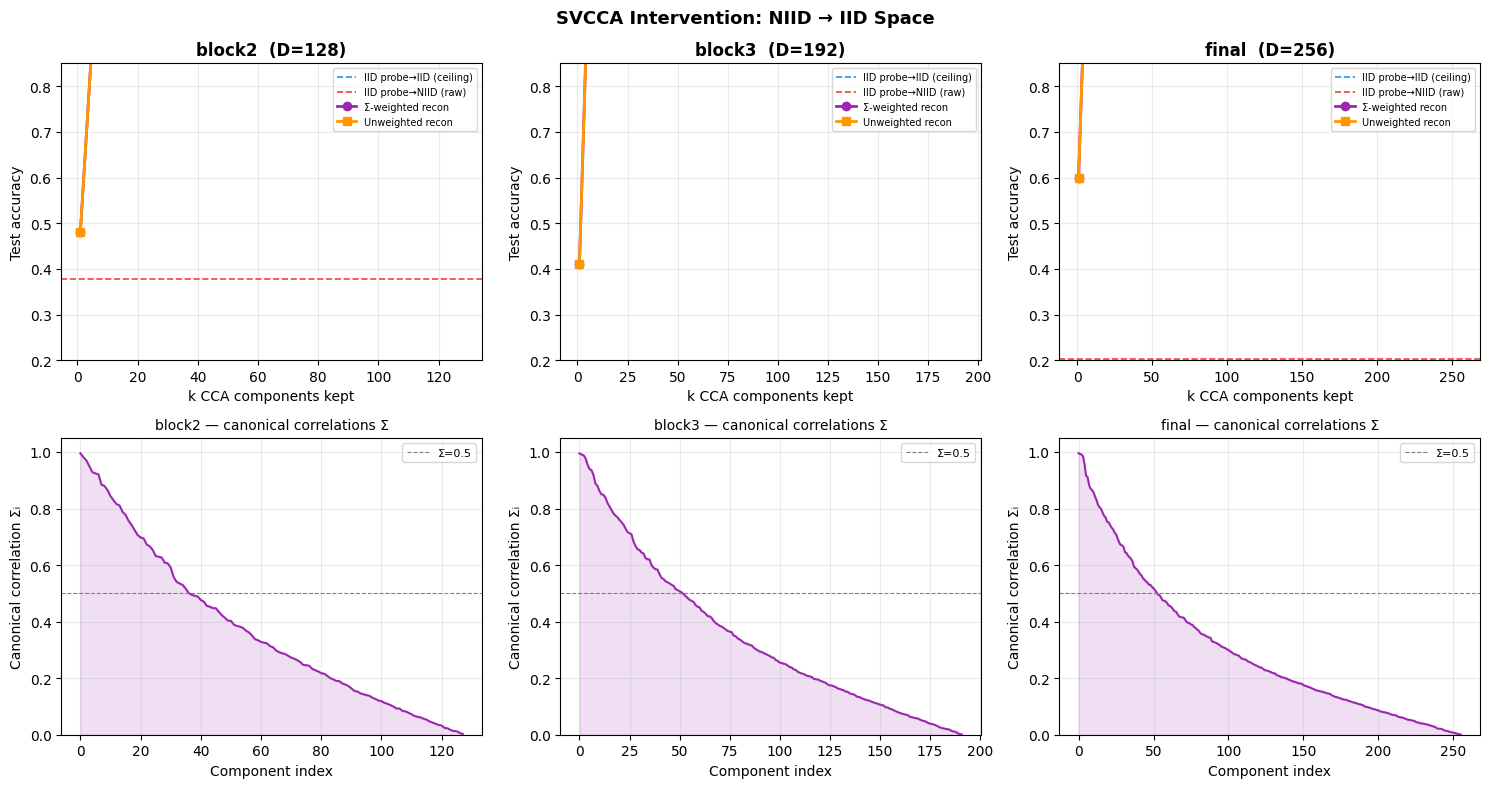

Saved: svcca_intervention.png


In [15]:
import torch
import numpy as np
import matplotlib.pyplot as plt

saved_probes = {}

for layer in ["block2", "block3", "final"]:
    input_dim    = iid_train[layer].tensors[0].shape[1]
    train_loader = DataLoader(iid_train[layer], batch_size=128, shuffle=True)
    print(f"Training IID probe for [{layer}]...")
    saved_probes[layer] = train_probe(train_loader, input_dim=input_dim, epochs=20)


def fit_svcca(X_train, Y_train):
    """
    Fits SVCCA on centred training features.
    Returns everything needed to project new data.

    X, Y : (N, D) — must be same shape (paired, same images)

    Returns dict with:
      mu_x, mu_y   : means for centring
      Vh_x, S_x    : IID SVD components
      Vh_y, S_y    : NIID SVD components
      A            : IID canonical directions  (D, D)
      B            : NIID canonical directions (D, D)
      Sigma        : canonical correlations    (D,)  — the quality indicator
    """
    mu_x  = X_train.mean(0);  X_c = X_train - mu_x
    mu_y  = Y_train.mean(0);  Y_c = Y_train - mu_y

    U_x, S_x, Vh_x = torch.linalg.svd(X_c, full_matrices=False)
    U_y, S_y, Vh_y = torch.linalg.svd(Y_c, full_matrices=False)

    # Cross-covariance in the whitened (left-singular) space
    M = U_x.T @ U_y              # (D, D)
    A, Sigma, Bh = torch.linalg.svd(M)
    B = Bh.T                     # (D, D), columns are NIID canonical directions

    return dict(mu_x=mu_x, mu_y=mu_y,
                Vh_x=Vh_x, S_x=S_x,
                Vh_y=Vh_y, S_y=S_y,
                A=A, B=B, Sigma=Sigma)


def reconstruct_niid_in_iid_space(Y_test, cca, k, weight_by_sigma=True):
    mu_y, Vh_y, S_y = cca["mu_y"], cca["Vh_y"], cca["S_y"]
    mu_x, Vh_x, S_x = cca["mu_x"], cca["Vh_x"], cca["S_x"]
    A, B, Sigma      = cca["A"],    cca["B"],    cca["Sigma"]

    S_y_inv = torch.diag(1.0 / torch.clamp(S_y, min=1e-5))
    S_x_mat = torch.diag(S_x)

    # Whiten NIID test features in NIID space
    Y_c      = Y_test - mu_y
    U_y_test = Y_c @ Vh_y.T @ S_y_inv       # (N_test, D)

    # Project to shared CCA space
    C_y = U_y_test @ B                        # (N_test, D)

    # Intervention: zero out components beyond k
    C_intervened = C_y.clone()
    if k < C_intervened.shape[1]:
        C_intervened[:, k:] = 0.0

    # Optionally weight kept components by their canonical correlation
    #    → reduces noise from weakly correlated directions
    if weight_by_sigma:
        weights = Sigma.clone()
        weights[k:] = 0.0
        C_intervened = C_intervened * weights.unsqueeze(0)

    # Reconstruct in IID feature space  (C_x ≈ C_y assumption)
    X_reconstructed_c = C_intervened @ A.T @ S_x_mat @ Vh_x
    return X_reconstructed_c + mu_x          # (N_test, D)


def evaluate_reconstruction(probe, X_reconstructed, labels):
    probe.eval()
    with torch.no_grad():
        logits = probe(X_reconstructed)
        _, preds = torch.max(logits, 1)
    return (preds == labels).float().mean().item()


def run_svcca_intervention(layer, k_values, weight_by_sigma=True):
    probe = saved_probes[layer]
    D     = iid_train[layer].tensors[0].shape[1]

    X_train = iid_train[layer].tensors[0].to(device).float()
    Y_train = niid_train[layer].tensors[0].to(device).float()
    Y_test  = niid_test[layer].tensors[0].to(device).float()
    labels  = niid_test[layer].tensors[1].to(device)

    # Fit CCA on training data
    print(f"\n[{layer}]  D={D}  fitting SVCCA...")
    cca = fit_svcca(X_train, Y_train)

    # Print Sigma to see how valid C_x ≈ C_y really is
    sig = cca["Sigma"].cpu().numpy()
    print(f"  Canonical correlations — mean: {sig.mean():.4f}  "
          f"top-10 mean: {sig[:10].mean():.4f}  "
          f"bottom-10 mean: {sig[-10:].mean():.4f}")

    # Baselines
    iid_test_loader  = DataLoader(iid_test[layer],  batch_size=128, shuffle=False)
    niid_test_loader = DataLoader(niid_test[layer], batch_size=128, shuffle=False)
    baseline_iid  = evaluate_probe(probe, iid_test_loader)
    baseline_niid = evaluate_probe(probe, niid_test_loader)   # raw cross-probe (no CCA)
    print(f"  Baseline — IID probe on IID test:  {baseline_iid:.4f}")
    print(f"  Baseline — IID probe on NIID test (raw, no CCA): {baseline_niid:.4f}")

    # k sweep
    print(f"\n  {'k':>5}  {'Σ_mean[:k]':>12}  {'acc (Σ-weighted)':>18}  {'acc (unweighted)':>18}")
    print(f"  {'-'*58}")
    results = []
    for k in k_values:
        k = min(k, D)
        sigma_mean_k = cca["Sigma"][:k].mean().item()

        acc_weighted   = evaluate_reconstruction(probe,
                             reconstruct_niid_in_iid_space(Y_test, cca, k, weight_by_sigma=True),
                             labels)
        acc_unweighted = evaluate_reconstruction(probe,
                             reconstruct_niid_in_iid_space(Y_test, cca, k, weight_by_sigma=False),
                             labels)

        print(f"  {k:>5}  {sigma_mean_k:>12.4f}  {acc_weighted:>18.4f}  {acc_unweighted:>18.4f}")
        results.append({"k": k, "sigma_mean": sigma_mean_k,
                        "acc_w": acc_weighted, "acc_u": acc_unweighted})

    return results, cca, baseline_iid, baseline_niid


layer_k = {
    "block2": [1, 5, 10, 20, 40, 64, 96, 128],
    "block3": [1, 5, 10, 20, 40, 64, 96, 128, 160, 192],
    "final":  [1, 5, 10, 20, 40, 64, 96, 128, 192, 256],
}

all_results = {}
for layer, ks in layer_k.items():
    res, cca, b_iid, b_niid = run_svcca_intervention(layer, ks)
    all_results[layer] = {"results": res, "b_iid": b_iid, "b_niid": b_niid,
                          "sigma": cca["Sigma"].cpu().numpy()}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("SVCCA Intervention: NIID → IID Space", fontsize=13, fontweight="bold")

for col, layer in enumerate(["block2", "block3", "final"]):
    data   = all_results[layer]
    res    = data["results"]
    sigma  = data["sigma"]
    D      = layer_k[layer][-1]

    ks      = [r["k"]     for r in res]
    acc_w   = [r["acc_w"] for r in res]
    acc_u   = [r["acc_u"] for r in res]

    ax = axes[0, col]
    ax.axhline(data["b_iid"],  color="#2196F3", lw=1.2, ls="--", label="IID probe→IID (ceiling)")
    ax.axhline(data["b_niid"], color="#F44336", lw=1.2, ls="--", label="IID probe→NIID (raw)")
    ax.plot(ks, acc_w,  "o-", color="#9C27B0", lw=2, label="Σ-weighted recon")
    ax.plot(ks, acc_u,  "s-", color="#FF9800", lw=2, label="Unweighted recon")
    ax.set_title(f"{layer}  (D={D})", fontweight="bold")
    ax.set_xlabel("k CCA components kept")
    ax.set_ylabel("Test accuracy")
    ax.set_ylim(0.2, 0.85)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.25)

    ax2 = axes[1, col]
    ax2.plot(sigma, color="#9C27B0", lw=1.5)
    ax2.axhline(0.5, color="grey", lw=0.8, ls="--", label="Σ=0.5")
    ax2.fill_between(range(len(sigma)), sigma, alpha=0.15, color="#9C27B0")
    ax2.set_title(f"{layer} — canonical correlations Σ", fontsize=10)
    ax2.set_xlabel("Component index")
    ax2.set_ylabel("Canonical correlation Σᵢ")
    ax2.set_ylim(0, 1.05)
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig("svcca_intervention.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: svcca_intervention.png")

In [16]:
import torch
import numpy as np

def cca_intervention_original_head(iid_train_ds, niid_train_ds, niid_test_ds, original_model, k_keep_list, device):
    # Extract raw tensors
    X_train = iid_train_ds.tensors[0].to(device).float()
    Y_train = niid_train_ds.tensors[0].to(device).float()

    Y_test = niid_test_ds.tensors[0].to(device).float()
    Y_test_labels = niid_test_ds.tensors[1].to(device)

    # Centering
    mu_x = X_train.mean(dim=0)
    mu_y = Y_train.mean(dim=0)

    X_c = X_train - mu_x
    Y_c = Y_train - mu_y

    # SVD of centered training data
    U_x, S_x, Vh_x = torch.linalg.svd(X_c, full_matrices=False)
    U_y, S_y, Vh_y = torch.linalg.svd(Y_c, full_matrices=False)

    # SVCCA: SVD of the cross-covariance of whitened spaces
    M = U_x.T @ U_y
    A, Sigma, Bh = torch.linalg.svd(M)
    B = Bh.T

    # Safe inverse for S_y
    S_y_inv = torch.diag(1.0 / torch.clamp(S_y, min=1e-5))
    S_x_mat = torch.diag(S_x)

    print(f"{'CCA Concepts Kept (k)':<25} | {'Original Head Accuracy':<15}")
    print("-" * 45)

    original_model.eval()

    results = {}
    for k in k_keep_list:
        # Step A & B: Map NIID test data to shared CCA space
        Y_test_c = Y_test - mu_y
        U_y_test = Y_test_c @ Vh_y.T @ S_y_inv
        C_y_test = U_y_test @ B

        # Step C: INTERVENTION (Zero out all components after index 'k')
        C_y_intervened = C_y_test.clone()
        if k < C_y_intervened.shape[1]:
            C_y_intervened[:, k:] = 0.0

        # Step D: Map back to the IID feature space
        X_test_reconstructed_c = C_y_intervened @ A.T @ S_x_mat @ Vh_x
        X_test_reconstructed = X_test_reconstructed_c + mu_x

        # Step E: Evaluate using the ORIGINAL MODEL HEAD
        with torch.no_grad():
            # Pass reconstructed features directly into the fc layer
            logits = original_model.fc(X_test_reconstructed)
            _, preds = torch.max(logits, 1)
            acc = (preds == Y_test_labels).sum().item() / len(Y_test_labels)

        results[k] = acc
        print(f"Top {k:<21} | {acc:.4f}")

    return results

layer = "final"
k_list = [1, 5, 10, 20, 30, 50, 100, 256]

print(f"\n--- CCA Intervention evaluated on ORIGINAL IID HEAD ---")
print(f"Baseline NIID Accuracy (No intervention): ~36.00%\n")

# Pass model_iid instead of the probe
intervention_results_original = cca_intervention_original_head(
    iid_train_ds=iid_train[layer],
    niid_train_ds=niid_train[layer],
    niid_test_ds=niid_test[layer],
    original_model=model_iid,
    k_keep_list=k_list,
    device=device
)


--- CCA Intervention evaluated on ORIGINAL IID HEAD ---
Baseline NIID Accuracy (No intervention): ~36.00%

CCA Concepts Kept (k)     | Original Head Accuracy
---------------------------------------------
Top 1                     | 0.6040
Top 5                     | 0.9874
Top 10                    | 0.9870
Top 20                    | 0.9887
Top 30                    | 0.9883
Top 50                    | 0.9914
Top 100                   | 0.9909
Top 256                   | 0.9914


In [17]:
import torch
import numpy as np

def cca_intervention_niid_head(iid_train_ds, niid_train_ds, niid_test_ds, original_niid_model, k_keep_list, device):
    """
    Translates NIID features into the shared SVCCA space, denoises them,
    maps them BACK to the NIID space, and evaluates with the ORIGINAL NIID head.
    """
    # 1. Extract raw tensors
    X_train = iid_train_ds.tensors[0].to(device).float()
    Y_train = niid_train_ds.tensors[0].to(device).float()

    Y_test = niid_test_ds.tensors[0].to(device).float()
    Y_test_labels = niid_test_ds.tensors[1].to(device)

    # 2. Centering
    mu_x = X_train.mean(dim=0)
    mu_y = Y_train.mean(dim=0)

    X_c = X_train - mu_x
    Y_c = Y_train - mu_y

    # 3. SVD of centered training data
    U_x, S_x, Vh_x = torch.linalg.svd(X_c, full_matrices=False)
    U_y, S_y, Vh_y = torch.linalg.svd(Y_c, full_matrices=False)

    # 4. SVCCA: SVD of the cross-covariance of whitened spaces
    M = U_x.T @ U_y
    A, Sigma, Bh = torch.linalg.svd(M)
    B = Bh.T

    # Safe inverse for S_y
    S_y_inv = torch.diag(1.0 / torch.clamp(S_y, min=1e-5))
    S_y_mat = torch.diag(S_y) # Used to reconstruct Y

    print(f"{'CCA Concepts Kept (k)':<25} | {'NIID Head Accuracy':<15}")
    print("-" * 45)

    original_niid_model.eval()

    results = {}
    for k in k_keep_list:
        # Step A & B: Map NIID test data to shared CCA space
        Y_test_c = Y_test - mu_y
        U_y_test = Y_test_c @ Vh_y.T @ S_y_inv
        C_y_test = U_y_test @ B

        # Step C: INTERVENTION (Zero out all components after index 'k')
        C_y_intervened = C_y_test.clone()
        if k < C_y_intervened.shape[1]:
            C_y_intervened[:, k:] = 0.0

        # Step D: Map BACK to the NIID feature space!
        # Because C_y_test = U_y @ B, then U_y_reconstructed = C_y_intervened @ B.T
        # Then we multiply by S_y and Vh_y to undo the SVD whitening
        U_y_reconstructed = C_y_intervened @ B.T
        Y_test_reconstructed_c = U_y_reconstructed @ S_y_mat @ Vh_y
        Y_test_reconstructed = Y_test_reconstructed_c + mu_y

        # Step E: Evaluate using the ORIGINAL NIID HEAD
        with torch.no_grad():
            logits = original_niid_model.fc(Y_test_reconstructed)
            _, preds = torch.max(logits, 1)
            acc = (preds == Y_test_labels).sum().item() / len(Y_test_labels)

        results[k] = acc
        print(f"Top {k:<21} | {acc:.4f}")

    return results

layer = "final"
k_list = [1, 5, 10, 20, 30, 50, 100, 256]

print(f"\n--- CCA Intervention evaluated on ORIGINAL NIID HEAD ---")
intervention_results_niid = cca_intervention_niid_head(
    iid_train_ds=iid_train[layer],
    niid_train_ds=niid_train[layer],
    niid_test_ds=niid_test[layer],
    original_niid_model=model_niid,
    k_keep_list=k_list,
    device=device
)


--- CCA Intervention evaluated on ORIGINAL NIID HEAD ---
CCA Concepts Kept (k)     | NIID Head Accuracy
---------------------------------------------
Top 1                     | 0.3853
Top 5                     | 0.4419
Top 10                    | 0.4528
Top 20                    | 0.4532
Top 30                    | 0.4448
Top 50                    | 0.4437
Top 100                   | 0.4310
Top 256                   | 0.4232
